<a href="https://colab.research.google.com/github/poonamkhot123/Machine-Learning-Practice-Hub/blob/main/Day_12_(End_to_end_Machine_Learning_Project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("/content/modified_placement_data.csv")

# steps
* 0. Preprocess + EDA + Feature Selection
* 1. Extract input and output Selection
* 2. Scale the values
* 3. Train test split
* 4. Evaluate the model/model selection
* 5. Deploy the model

In [4]:
df.head()

,cgpa,iq,placement
0,"6,8",123.0,Yes
1,"5,9",106.0,No
2,"5,3",121.0,No
3,"7,4",132.0,Yes
4,"5,8",142.0,No


In [5]:
df.shape

(100, 3)

In [6]:
df.head()

,cgpa,iq,placement
0,"6,8",123.0,Yes
1,"5,9",106.0,No
2,"5,3",121.0,No
3,"7,4",132.0,Yes
4,"5,8",142.0,No


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


In [8]:
import matplotlib.pyplot as plt


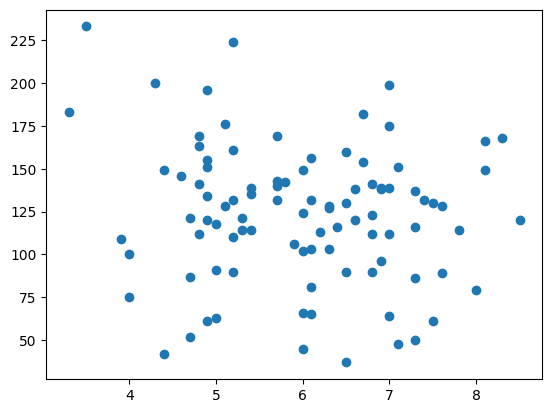

In [40]:
df['cgpa'] = df['cgpa'].astype(str).str.replace(',', '.', regex=False).astype(float)
plt.scatter(df['cgpa'],df['iq'])

In [12]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [13]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [14]:
y

,placement
0,Yes
1,No
2,No
3,Yes
4,No
...,...
95,No
96,No
97,Yes
98,Yes


In [15]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.1)

In [16]:
x_train

,cgpa,iq
33,6.0,149.0
85,NaN,166.0
87,5.7,132.0
64,7.0,64.0
32,7.0,139.0
...,...,...
3,7.4,132.0
69,8.5,120.0
84,5.7,169.0
94,4.7,52.0


In [17]:
y_train

,placement
33,No
85,Yes
87,Yes
64,Yes
32,Yes
...,...
3,Yes
69,Yes
84,No
94,No


In [18]:
x_test

,cgpa,iq
56,6.1,65.0
24,4.7,121.0
39,4.6,146.0
30,7.6,128.0
45,6.0,66.0
4,5.8,142.0
7,5.0,63.0
55,7.8,114.0
74,6.7,154.0
42,7.6,89.0


In [19]:
y_test

,placement
56,No
24,No
39,No
30,Yes
45,Yes
4,No
7,No
55,Yes
74,Yes
42,Yes


In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

In [22]:
x_train = scaler.fit_transform(x_train)

In [23]:
x_train

array([[ 0.03071765,  0.59399591],
       [        nan,  1.01867523],
       [-0.2303824 ,  0.16931659],
       [ 0.90105118, -1.52940068],
       [ 0.90105118,  0.34418455],
       [ 1.16215124, -0.23038159],
       [-0.66554917, -0.38026841],
       [        nan,  0.39414682],
       [-0.83961587, -0.85491   ],
       [ 0.55291777, -0.13045705],
       [-0.92664923,  1.76810932],
       [ 1.33621794,  0.11935432],
       [-1.7099494 , -0.63007977],
       [ 1.16215124, -0.97981568],
       [ 0.72698447, -0.05551364],
       [-0.92664923,  0.74388273],
       [-0.2303824 ,  0.36916568],
       [-0.92664923,  0.64395818],
       [        nan,  0.81882614],
       [ 1.85841806,  1.01867523],
       [-1.44884934,  1.86803386],
       [-0.57851581, -0.10547591],
       [ 0.11775101, -1.10472136],
       [-1.01368258,  0.94373182],
       [-0.49148246,  0.24426   ],
       [ 1.33621794, -1.60434409],
       [ 0.11775101,  0.76886386],
       [ 0.81401783,  0.31920341],
       [ 0.63995112,

In [24]:
x_test = scaler.transform(x_test)

In [25]:
x_test

array([[ 0.11775101, -1.50441954],
       [-1.10071593, -0.10547591],
       [-1.18774928,  0.5190525 ],
       [ 1.4232513 ,  0.06939205],
       [ 0.03071765, -1.47943841],
       [-0.14334905,  0.41912795],
       [-0.83961587, -1.55438182],
       [ 1.597318  , -0.28034386],
       [ 0.63995112,  0.71890159],
       [ 1.4232513 , -0.90487227]])

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
clf = LogisticRegression()

In [41]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

clf.fit(x_train,y_train)

LogisticRegression()

In [30]:
clf.fit(x_train,y_train)

LogisticRegression()

In [33]:
y_pred = clf.predict(x_test)

In [34]:
y_test

,placement
56,No
24,No
39,No
30,Yes
45,Yes
4,No
7,No
55,Yes
74,Yes
42,Yes


In [35]:
from sklearn.metrics import accuracy_score

In [36]:
accuracy_score(y_test,y_pred)

0.8

In [ ]:
# this project has issue with the last some codes so this project is incomplete.